# Lab 2 — Getting Started with IDE, NumPy, Pandas, Scikit-Learn, Matplotlib, Tensors and Setting Up the Working Environment
## Global Seismic Activity Analysis

---

### Lab Overview

| Field | Details |
|---|---|
| **Lab Name** | Getting Started with Python Libraries and Working Environment |
| **Dataset** | Synthetic Global Seismic Activity Dataset (800 earthquake records) |
| **Domain** | Geoscience / Environmental Data Analysis |
| **Tools Covered** | NumPy, Pandas, Scikit-Learn, Matplotlib, TensorFlow Tensors |

---

### Problem Statement

> **Can we characterize global earthquake patterns — by magnitude, depth, region, and frequency — and build a basic preprocessing pipeline to prepare seismic data for machine learning?**
>
> Earthquakes cause enormous loss of life and infrastructure damage every year. Understanding historical seismic patterns is the first step toward building predictive systems. In this lab, we use a synthetic but realistic global earthquake dataset to explore all the core Python data science libraries. The lab is designed as a hands-on tour of the full data science environment: from setting up packages and understanding tensor operations, to visualising seismic distributions and building a Scikit-Learn preprocessing pipeline.

### Learning Objectives
- Set up and verify a complete Python data science environment
- Master core NumPy array operations on real-style numerical data
- Load, explore, and manipulate data using Pandas DataFrames
- Build a preprocessing pipeline using Scikit-Learn
- Create informative plots using Matplotlib and Seaborn
- Understand TensorFlow tensors and their relationship to NumPy arrays

---
## Section 0: Environment Setup

Before anything else, we verify the environment and install/upgrade any required packages.

In [1]:
# Verify Python and library versions
import sys
print(f'Python version : {sys.version}')

# Install / upgrade key libraries if needed
# !pip install -q numpy pandas scikit-learn matplotlib seaborn tensorflow

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

print('\n--- Library Versions ---')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Scikit-Learn: {sklearn.__version__}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'TensorFlow : {tf.__version__}')
print('\nEnvironment ready.')

Python version : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]

--- Library Versions ---
NumPy      : 2.0.2
Pandas     : 2.2.2
Scikit-Learn: 1.6.1
Matplotlib : 3.10.0
TensorFlow : 2.19.0

Environment ready.


---
## Section 1: Dataset Generation

We generate a synthetic **Global Seismic Activity Dataset** with 800 earthquake records across 10 seismic regions. Each record contains:

| Column | Description |
|---|---|
| `region` | Tectonic region where the earthquake occurred |
| `latitude` | Geographic latitude (-90 to 90) |
| `longitude` | Geographic longitude (-180 to 180) |
| `depth_km` | Focal depth in kilometres (5 to 700) |
| `magnitude` | Richter magnitude (2.0 to 9.5) |
| `duration_sec` | Estimated shaking duration in seconds |
| `felt_radius_km` | Estimated radius within which quake was felt |
| `aftershocks` | Number of aftershocks recorded |
| `tsunami_warning` | Whether a tsunami warning was issued |
| `year` | Year of occurrence (2000 to 2024) |

In [2]:
np.random.seed(21)
N = 800

REGIONS = ['Pacific Ring', 'Himalayan Belt', 'Mediterranean', 'Caribbean',
           'East Africa Rift', 'Aleutian Arc', 'Sumatra Fault', 'Andes Belt',
           'Japan Trench', 'New Zealand']

region_arr   = np.random.choice(REGIONS, N)
latitude     = np.clip(np.random.uniform(-60, 70, N), -90, 90).round(3)
longitude    = np.random.uniform(-180, 180, N).round(3)

# Depth: shallow (5-70km), intermediate (70-300km), deep (300-700km)
depth_km     = np.clip(np.random.exponential(80, N) + 5, 5, 700).round(1)

# Magnitude: mostly moderate (4-6), some large, rare catastrophic
magnitude    = np.clip(np.random.normal(5.2, 1.1, N), 2.0, 9.5).round(1)

# Duration increases with magnitude
duration_sec = np.clip(magnitude * 8 + np.random.normal(0, 5, N), 5, 120).round(1)

# Felt radius scales with magnitude, reduced by depth
felt_radius  = np.clip((10 ** (magnitude * 0.6)) - depth_km * 0.3
                       + np.random.normal(0, 20, N), 10, 1500).round(1)

# Aftershocks correlated with magnitude
aftershocks  = np.clip((magnitude ** 2.2 * np.random.uniform(0.3, 1.5, N)).astype(int), 0, 200)

# Tsunami warning issued for large shallow coastal quakes
tsunami_prob = np.where((magnitude >= 7.0) & (depth_km < 80), 0.65, 0.04)
tsunami      = np.array([np.random.choice([True, False], p=[p, 1-p]) for p in tsunami_prob])

year         = np.random.choice(range(2000, 2025), N)

df = pd.DataFrame({
    'region'         : region_arr,
    'latitude'       : latitude,
    'longitude'      : longitude,
    'depth_km'       : depth_km,
    'magnitude'      : magnitude,
    'duration_sec'   : duration_sec,
    'felt_radius_km' : felt_radius,
    'aftershocks'    : aftershocks,
    'tsunami_warning': tsunami,
    'year'           : year
})

# Inject 20 missing values for cleaning exercise
for col in ['depth_km', 'felt_radius_km', 'duration_sec']:
    df.loc[np.random.choice(df.index, 7, replace=False), col] = np.nan

print(f'Dataset shape  : {df.shape}')
print(f'Magnitude range: {df.magnitude.min()} – {df.magnitude.max()}')
print(f'Depth range    : {df.depth_km.min()} – {df.depth_km.max()} km')
print(f'Tsunami events : {df.tsunami_warning.sum()}')
df.head(8)

Dataset shape  : (800, 10)
Magnitude range: 2.0 – 9.0
Depth range    : 5.0 – 683.4 km
Tsunami events : 53


,region,latitude,longitude,depth_km,magnitude,duration_sec,felt_radius_km,aftershocks,tsunami_warning,year
0,New Zealand,20.474,-149.218,5.4,4.4,42.5,453.4,38,False,2005
1,Japan Trench,-13.934,28.163,162.4,5.8,44.0,1500.0,17,False,2010
2,East Africa Rift,63.884,102.780,233.4,4.9,45.5,757.8,28,False,2017
3,Pacific Ring,-1.463,7.883,24.2,5.3,45.4,1494.4,30,False,2016
4,Pacific Ring,-45.052,-34.626,39.9,4.3,39.7,377.7,16,False,2011
5,Japan Trench,-6.876,-29.878,201.3,4.9,36.6,802.5,41,False,2007
6,Caribbean,18.869,-153.680,22.0,6.5,59.5,1500.0,48,False,2024
7,Mediterranean,39.246,-151.252,5.9,5.8,48.6,1500.0,54,False,2010


---
## Section 2: NumPy — Numerical Operations on Seismic Data

In [3]:
# ── 2.1 Array creation and properties ──────────────────────────────────────
mag_arr   = df['magnitude'].values
depth_arr = df['depth_km'].dropna().values
felt_arr  = df['felt_radius_km'].dropna().values

print('=== Array Properties ===')
print(f'Magnitude  — shape: {mag_arr.shape}, dtype: {mag_arr.dtype}')
print(f'Depth      — shape: {depth_arr.shape}, dtype: {depth_arr.dtype}')

# ── 2.2 Descriptive statistics ─────────────────────────────────────────────
print('\n=== Magnitude Statistics ===')
print(f'Mean     : {np.mean(mag_arr):.3f}')
print(f'Median   : {np.median(mag_arr):.3f}')
print(f'Std Dev  : {np.std(mag_arr):.3f}')
print(f'Min/Max  : {np.min(mag_arr):.1f} / {np.max(mag_arr):.1f}')
print(f'25th pct : {np.percentile(mag_arr, 25):.2f}')
print(f'75th pct : {np.percentile(mag_arr, 75):.2f}')
print(f'IQR      : {np.percentile(mag_arr, 75) - np.percentile(mag_arr, 25):.2f}')

=== Array Properties ===
Magnitude  — shape: (800,), dtype: float64
Depth      — shape: (793,), dtype: float64

=== Magnitude Statistics ===
Mean     : 5.227
Median   : 5.200
Std Dev  : 1.089
Min/Max  : 2.0 / 9.0
25th pct : 4.47
75th pct : 6.00
IQR      : 1.53


In [4]:
# ── 2.3 Broadcasting and vectorised operations ─────────────────────────────
# Energy released scales approximately as 10^(1.5 * M)
energy_joules = 10 ** (1.5 * mag_arr + 4.8)
energy_relative = energy_joules / energy_joules.min()   # broadcasting scalar division

print('=== Seismic Energy (Broadcasting) ===')
print(f'Min energy  : {energy_joules.min():.2e} J')
print(f'Max energy  : {energy_joules.max():.2e} J')
print(f'Max/Min ratio: {energy_relative.max():.0f}x')

# ── 2.4 Boolean masking ────────────────────────────────────────────────────
major   = mag_arr >= 7.0
moderate = (mag_arr >= 5.0) & (mag_arr < 7.0)
minor   = mag_arr < 5.0

print('\n=== Earthquake Classification (Boolean Masking) ===')
print(f'Major   (M >= 7.0) : {major.sum():>4} events ({major.mean()*100:.1f}%)')
print(f'Moderate (5.0-6.9) : {moderate.sum():>4} events ({moderate.mean()*100:.1f}%)')
print(f'Minor    (< 5.0)   : {minor.sum():>4} events ({minor.mean()*100:.1f}%)')

# ── 2.5 Vectorised np.where classification ─────────────────────────────────
depth_class = np.where(depth_arr < 70, 'Shallow',
              np.where(depth_arr < 300, 'Intermediate', 'Deep'))
vals, counts = np.unique(depth_class, return_counts=True)
print('\n=== Depth Classification (np.where) ===')
for v, c in zip(vals, counts):
    print(f'  {v:15s}: {c} events')

=== Seismic Energy (Broadcasting) ===
Min energy  : 6.31e+07 J
Max energy  : 2.00e+18 J
Max/Min ratio: 31622776602x

=== Earthquake Classification (Boolean Masking) ===
Major   (M >= 7.0) :   53 events (6.6%)
Moderate (5.0-6.9) :  411 events (51.4%)
Minor    (< 5.0)   :  336 events (42.0%)

=== Depth Classification (np.where) ===
  Deep           : 25 events
  Intermediate   : 345 events
  Shallow        : 423 events


=== NumPy Correlation Matrix ===
                   Magnitude        Depth  Felt Radius     Duration  Aftershocks
Magnitude             1.0000       0.0195       0.8847       0.8641       0.6988
Depth                 0.0195       1.0000      -0.0266       0.0104       0.0254
Felt Radius           0.8847      -0.0266       1.0000       0.7569       0.5949
Duration              0.8641       0.0104       0.7569       1.0000       0.6117
Aftershocks           0.6988       0.0254       0.5949       0.6117       1.0000


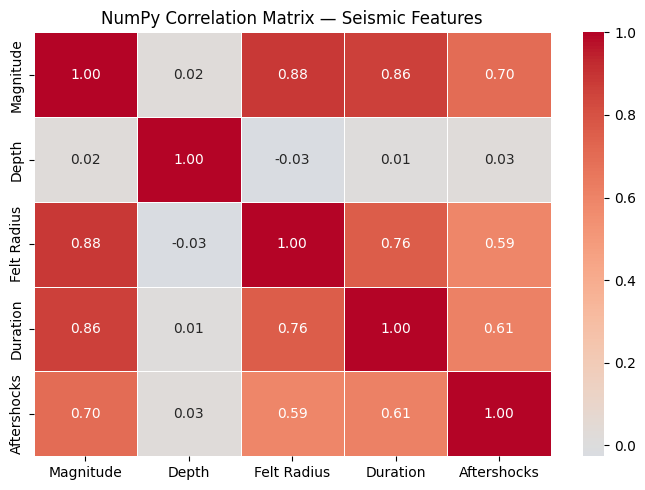

In [5]:
# ── 2.6 Linear algebra: correlation and matrix operations ─────────────────
clean = df[['magnitude','depth_km','felt_radius_km','duration_sec','aftershocks']].dropna()
feature_matrix = clean.values.T          # shape: (5, n_samples)
corr_matrix    = np.corrcoef(feature_matrix)
feature_labels = ['Magnitude','Depth','Felt Radius','Duration','Aftershocks']

print('=== NumPy Correlation Matrix ===')
header = ''.join(f'{l:>13}' for l in feature_labels)
print(f'{'':15}{header}')
for i, label in enumerate(feature_labels):
    row = ''.join(f'{corr_matrix[i,j]:>13.4f}' for j in range(len(feature_labels)))
    print(f'{label:15}{row}')

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            xticklabels=feature_labels, yticklabels=feature_labels,
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NumPy Correlation Matrix — Seismic Features')
plt.tight_layout()
plt.show()

---
## Section 3: Pandas — Data Exploration and Wrangling

In [6]:
# ── 3.1 Basic exploration ──────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
display(df.describe().round(3))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           800 non-null    object 
 1   latitude         800 non-null    float64
 2   longitude        800 non-null    float64
 3   depth_km         793 non-null    float64
 4   magnitude        800 non-null    float64
 5   duration_sec     793 non-null    float64
 6   felt_radius_km   793 non-null    float64
 7   aftershocks      800 non-null    int64  
 8   tsunami_warning  800 non-null    bool   
 9   year             800 non-null    int64  
dtypes: bool(1), float64(6), int64(2), object(1)
memory usage: 57.2+ KB

=== Statistical Summary ===


,latitude,longitude,depth_km,magnitude,duration_sec,felt_radius_km,aftershocks,year
count,800.000,800.000,793.000,800.000,793.000,793.000,800.000,800.000
mean,6.439,2.864,89.518,5.227,42.003,999.856,35.801,2012.188
std,37.654,104.040,86.323,1.090,9.858,546.436,21.634,7.231
min,-59.927,-179.746,5.000,2.000,13.300,10.000,1.000,2000.000
25%,-27.103,-90.319,28.000,4.475,35.200,446.800,20.000,2006.000
50%,7.223,4.318,63.600,5.200,41.700,1293.600,31.000,2012.000
75%,39.308,95.345,121.500,6.000,49.000,1500.000,47.000,2019.000
max,69.858,179.060,683.400,9.000,72.200,1500.000,140.000,2024.000


In [7]:
# ── 3.2 Missing value detection and imputation ─────────────────────────────
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])

for col in ['depth_km', 'felt_radius_km', 'duration_sec']:
    median_val = df[col].median()
    df[col]    = df[col].fillna(median_val)
    print(f"  Filled '{col}' NaNs with median: {median_val:.2f}")

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

=== Missing Values ===
depth_km          7
duration_sec      7
felt_radius_km    7
dtype: int64
  Filled 'depth_km' NaNs with median: 63.60
  Filled 'felt_radius_km' NaNs with median: 1293.60
  Filled 'duration_sec' NaNs with median: 41.70

Remaining missing values: 0


In [8]:
# ── 3.3 Feature engineering ────────────────────────────────────────────────
df['magnitude_class'] = pd.cut(
    df['magnitude'],
    bins=[0, 4.9, 5.9, 6.9, 10],
    labels=['Minor', 'Moderate', 'Strong', 'Major']
)
df['depth_class'] = pd.cut(
    df['depth_km'],
    bins=[0, 70, 300, 800],
    labels=['Shallow', 'Intermediate', 'Deep']
)
# Log-transformed energy (more interpretable than raw joules)
df['log_energy'] = (1.5 * df['magnitude'] + 4.8).round(3)
df['decade']     = (df['year'] // 10 * 10).astype(str) + 's'

print('New columns added: magnitude_class, depth_class, log_energy, decade')
display(df[['magnitude','depth_km','magnitude_class','depth_class','log_energy','decade']].head(8))

New columns added: magnitude_class, depth_class, log_energy, decade


,magnitude,depth_km,magnitude_class,depth_class,log_energy,decade
0,4.4,5.4,Minor,Shallow,11.40,2000s
1,5.8,162.4,Moderate,Intermediate,13.50,2010s
2,4.9,233.4,Minor,Intermediate,12.15,2010s
3,5.3,24.2,Moderate,Shallow,12.75,2010s
4,4.3,39.9,Minor,Shallow,11.25,2010s
5,4.9,201.3,Minor,Intermediate,12.15,2000s
6,6.5,22.0,Strong,Shallow,14.55,2020s
7,5.8,5.9,Moderate,Shallow,13.50,2010s


In [9]:
# ── 3.4 GroupBy analysis ───────────────────────────────────────────────────
print('=== Average Features by Region (Top 5 by Event Count) ===')
region_stats = df.groupby('region').agg(
    event_count   = ('magnitude', 'count'),
    avg_magnitude = ('magnitude', 'mean'),
    avg_depth     = ('depth_km', 'mean'),
    max_magnitude = ('magnitude', 'max'),
    tsunami_events= ('tsunami_warning', 'sum')
).round(2).sort_values('event_count', ascending=False)
display(region_stats)

print('\n=== Events by Decade ===')
decade_counts = df.groupby('decade')['magnitude'].agg(['count','mean']).round(2)
decade_counts.columns = ['Event Count', 'Avg Magnitude']
display(decade_counts)

print('\n=== Tsunami Events by Depth Class ===')
display(df.groupby('depth_class')['tsunami_warning'].value_counts(normalize=True).round(3))

=== Average Features by Region (Top 5 by Event Count) ===


,event_count,avg_magnitude,avg_depth,max_magnitude,tsunami_events
region,,,,,
New Zealand,96,5.32,76.90,7.9,5
Aleutian Arc,84,5.38,82.26,7.7,10
Japan Trench,83,4.96,99.24,6.6,1
Himalayan Belt,82,5.36,92.97,8.4,5
Caribbean,82,5.31,87.56,7.6,5
Pacific Ring,81,5.20,105.81,8.7,6
Mediterranean,80,4.89,94.59,8.0,7
Sumatra Fault,75,5.25,84.82,7.7,3
East Africa Rift,71,5.29,94.26,8.3,4



=== Events by Decade ===


,Event Count,Avg Magnitude
decade,,
2000s,311,5.32
2010s,316,5.13
2020s,173,5.24



=== Tsunami Events by Depth Class ===


depth_class   tsunami_warning
Shallow       False              0.914
              True               0.086
Intermediate  False              0.959
              True               0.041
Deep          False              0.920
              True               0.080
Name: proportion, dtype: float64

---
## Section 4: Scikit-Learn — Preprocessing Pipeline

In [10]:
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print('Scikit-Learn preprocessing tools imported.')

Scikit-Learn preprocessing tools imported.


In [11]:
# ── 4.1 Encoding categorical features ─────────────────────────────────────
le_region = LabelEncoder()
df['region_enc'] = le_region.fit_transform(df['region'])

print('=== Label Encoding — Region ===')
for code, name in enumerate(le_region.classes_):
    print(f'  {code:2d} -> {name}')

=== Label Encoding — Region ===
   0 -> Aleutian Arc
   1 -> Andes Belt
   2 -> Caribbean
   3 -> East Africa Rift
   4 -> Himalayan Belt
   5 -> Japan Trench
   6 -> Mediterranean
   7 -> New Zealand
   8 -> Pacific Ring
   9 -> Sumatra Fault


In [12]:
# ── 4.2 Scaling comparison: StandardScaler vs MinMaxScaler ────────────────
mag_sample = df['magnitude'].values.reshape(-1, 1)

std_scaler = StandardScaler()
mm_scaler  = MinMaxScaler()

mag_std = std_scaler.fit_transform(mag_sample).flatten()
mag_mm  = mm_scaler.fit_transform(mag_sample).flatten()

print('=== Scaling Comparison — Magnitude ===')
print(f'Original  — Mean: {mag_sample.mean():.3f}, Std: {mag_sample.std():.3f}, Range: [{mag_sample.min():.1f}, {mag_sample.max():.1f}]')
print(f'StandardScaler — Mean: {mag_std.mean():.3f}, Std: {mag_std.std():.3f}, Range: [{mag_std.min():.2f}, {mag_std.max():.2f}]')
print(f'MinMaxScaler   — Mean: {mag_mm.mean():.3f}, Std: {mag_mm.std():.3f}, Range: [{mag_mm.min():.2f}, {mag_mm.max():.2f}]')

=== Scaling Comparison — Magnitude ===
Original  — Mean: 5.227, Std: 1.089, Range: [2.0, 9.0]
StandardScaler — Mean: -0.000, Std: 1.000, Range: [-2.96, 3.47]
MinMaxScaler   — Mean: 0.461, Std: 0.156, Range: [0.00, 1.00]


In [13]:
# ── 4.3 Full preprocessing pipeline + Logistic Regression ─────────────────
# Binary classification: tsunami_warning (True/False) prediction
features = ['magnitude', 'depth_km', 'felt_radius_km', 'duration_sec',
            'aftershocks', 'latitude', 'longitude', 'region_enc']
X = df[features].values
y = df['tsunami_warning'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=500, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f'Train size : {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Warning', 'Tsunami Warning']))

Train size : 600 | Test size: 200
Test Accuracy: 93.00%

=== Classification Report ===
                 precision    recall  f1-score   support

     No Warning       0.93      0.99      0.96       187
Tsunami Warning       0.00      0.00      0.00        13

       accuracy                           0.93       200
      macro avg       0.47      0.50      0.48       200
   weighted avg       0.87      0.93      0.90       200



---
## Section 5: Matplotlib and Seaborn — Plotting and Visualisation

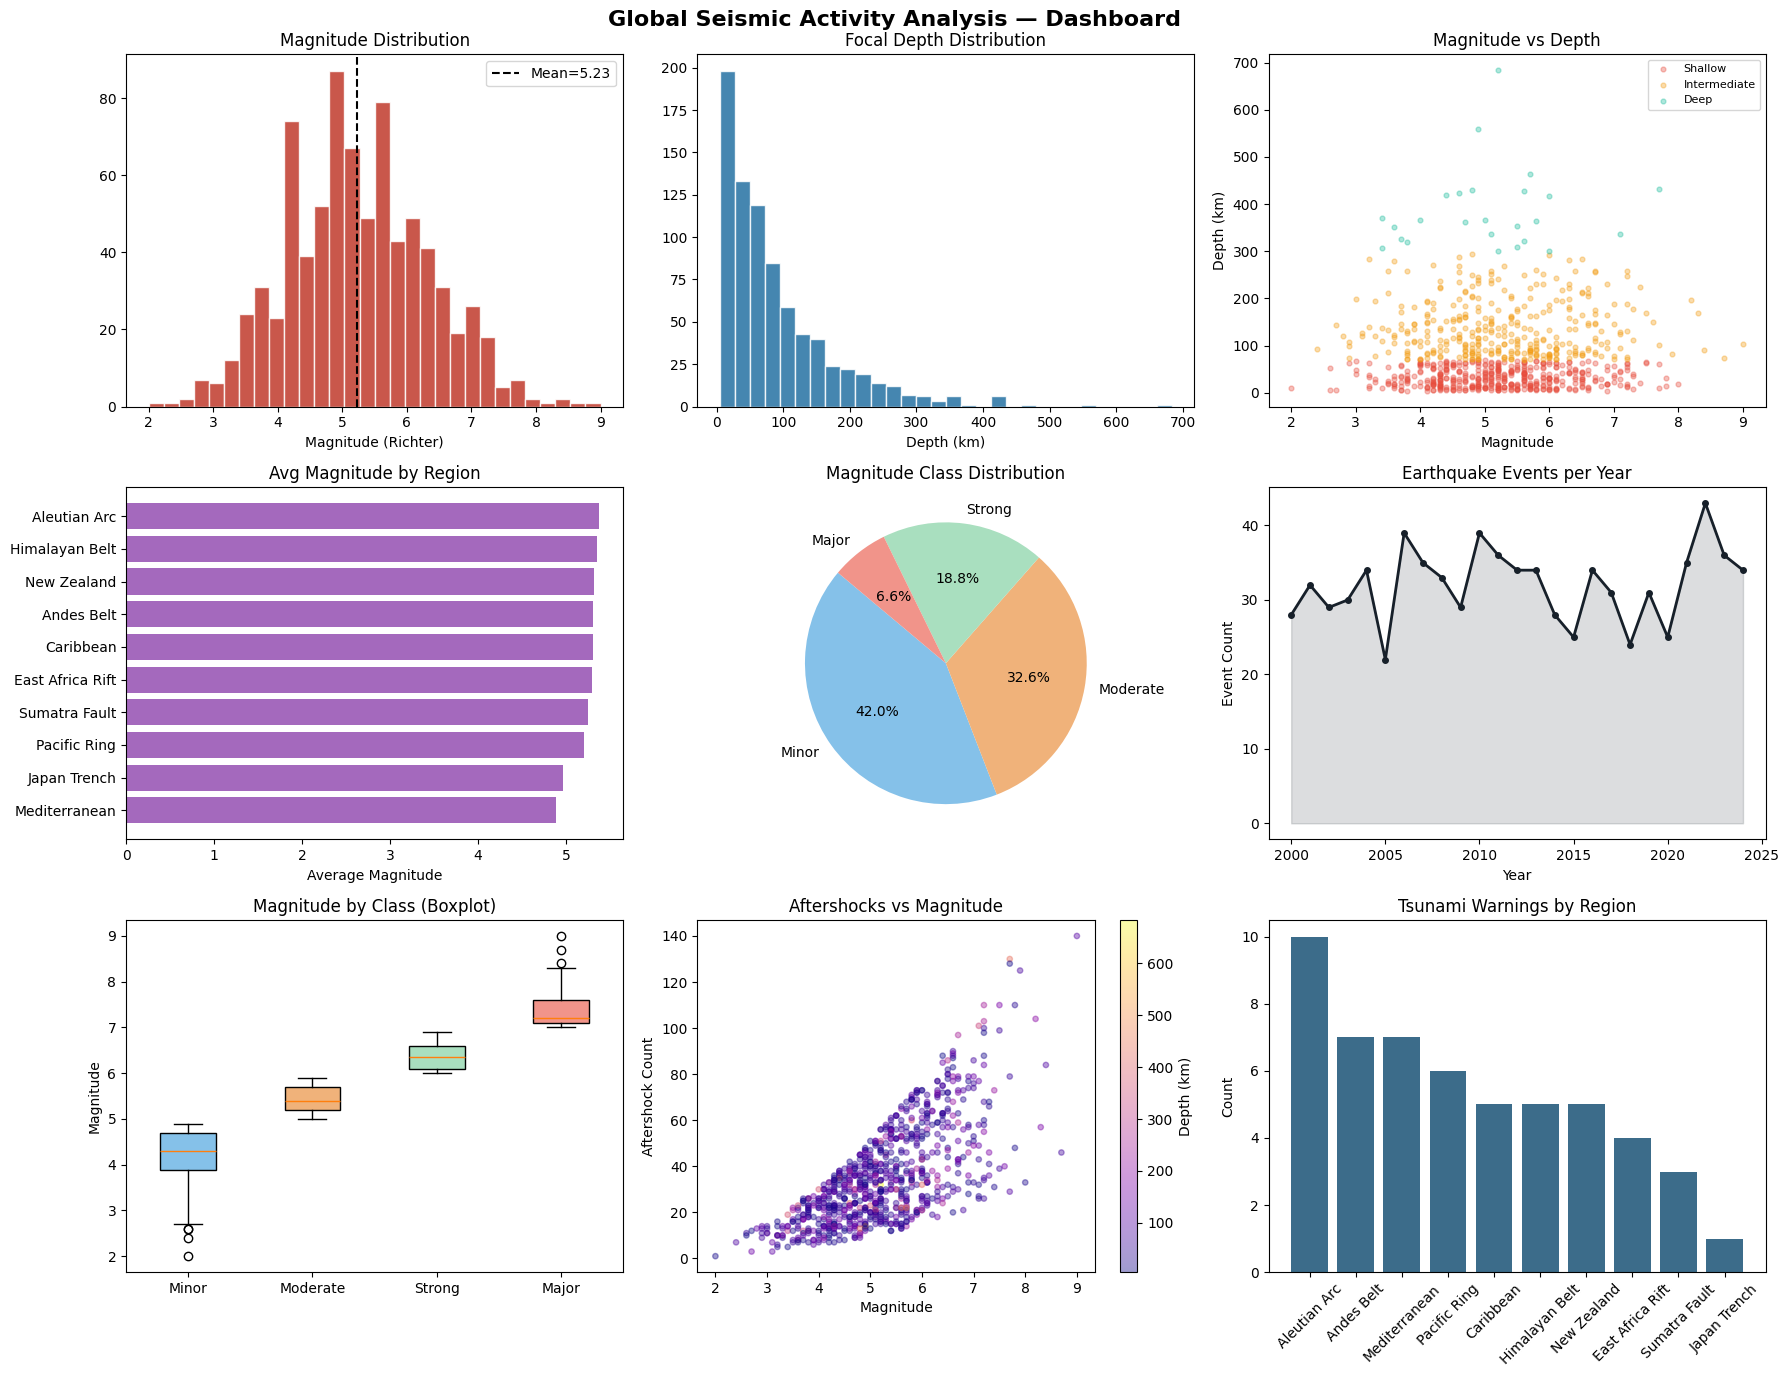

In [14]:
# ── 5.1 Comprehensive dashboard ────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Global Seismic Activity Analysis — Dashboard', fontsize=16, fontweight='bold')

# 1. Magnitude histogram
axes[0,0].hist(df['magnitude'], bins=30, color='#C0392B', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['magnitude'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={df.magnitude.mean():.2f}')
axes[0,0].set_title('Magnitude Distribution')
axes[0,0].set_xlabel('Magnitude (Richter)')
axes[0,0].legend()

# 2. Depth histogram
axes[0,1].hist(df['depth_km'], bins=30, color='#2471A3', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Focal Depth Distribution')
axes[0,1].set_xlabel('Depth (km)')

# 3. Magnitude vs Depth scatter (coloured by class)
colors = {'Shallow':'#E74C3C', 'Intermediate':'#F39C12', 'Deep':'#1ABC9C'}
for cls, grp in df.groupby('depth_class'):
    axes[0,2].scatter(grp['magnitude'], grp['depth_km'], alpha=0.35, s=12,
                      label=str(cls), color=colors.get(str(cls), 'grey'))
axes[0,2].set_title('Magnitude vs Depth')
axes[0,2].set_xlabel('Magnitude')
axes[0,2].set_ylabel('Depth (km)')
axes[0,2].legend(fontsize=8)

# 4. Average magnitude by region (horizontal bar)
reg_mag = df.groupby('region')['magnitude'].mean().sort_values()
axes[1,0].barh(reg_mag.index, reg_mag.values, color='#8E44AD', alpha=0.8)
axes[1,0].set_title('Avg Magnitude by Region')
axes[1,0].set_xlabel('Average Magnitude')

# 5. Magnitude class pie
mc = df['magnitude_class'].value_counts()
axes[1,1].pie(mc.values, labels=mc.index, autopct='%1.1f%%',
               colors=['#85C1E9','#F0B27A','#A9DFBF','#F1948A'], startangle=140)
axes[1,1].set_title('Magnitude Class Distribution')

# 6. Events per year line chart
yearly = df.groupby('year').size()
axes[1,2].plot(yearly.index, yearly.values, color='#17202A', linewidth=2, marker='o', markersize=4)
axes[1,2].fill_between(yearly.index, yearly.values, alpha=0.15, color='#17202A')
axes[1,2].set_title('Earthquake Events per Year')
axes[1,2].set_xlabel('Year')
axes[1,2].set_ylabel('Event Count')

# 7. Boxplot: magnitude by magnitude class
order = ['Minor','Moderate','Strong','Major']
df_box = df.dropna(subset=['magnitude_class'])
data_by_class = [df_box[df_box['magnitude_class']==c]['magnitude'].values for c in order]
bp = axes[2,0].boxplot(data_by_class, labels=order, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#85C1E9','#F0B27A','#A9DFBF','#F1948A']):
    patch.set_facecolor(color)
axes[2,0].set_title('Magnitude by Class (Boxplot)')
axes[2,0].set_ylabel('Magnitude')

# 8. Aftershocks vs Magnitude scatter
sc = axes[2,1].scatter(df['magnitude'], df['aftershocks'], c=df['depth_km'],
                         cmap='plasma', alpha=0.4, s=15)
plt.colorbar(sc, ax=axes[2,1], label='Depth (km)')
axes[2,1].set_title('Aftershocks vs Magnitude')
axes[2,1].set_xlabel('Magnitude')
axes[2,1].set_ylabel('Aftershock Count')

# 9. Tsunami events by region
ts_region = df[df['tsunami_warning']==True].groupby('region').size().sort_values(ascending=False)
axes[2,2].bar(ts_region.index, ts_region.values, color='#1A5276', alpha=0.85)
axes[2,2].set_title('Tsunami Warnings by Region')
axes[2,2].set_ylabel('Count')
axes[2,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

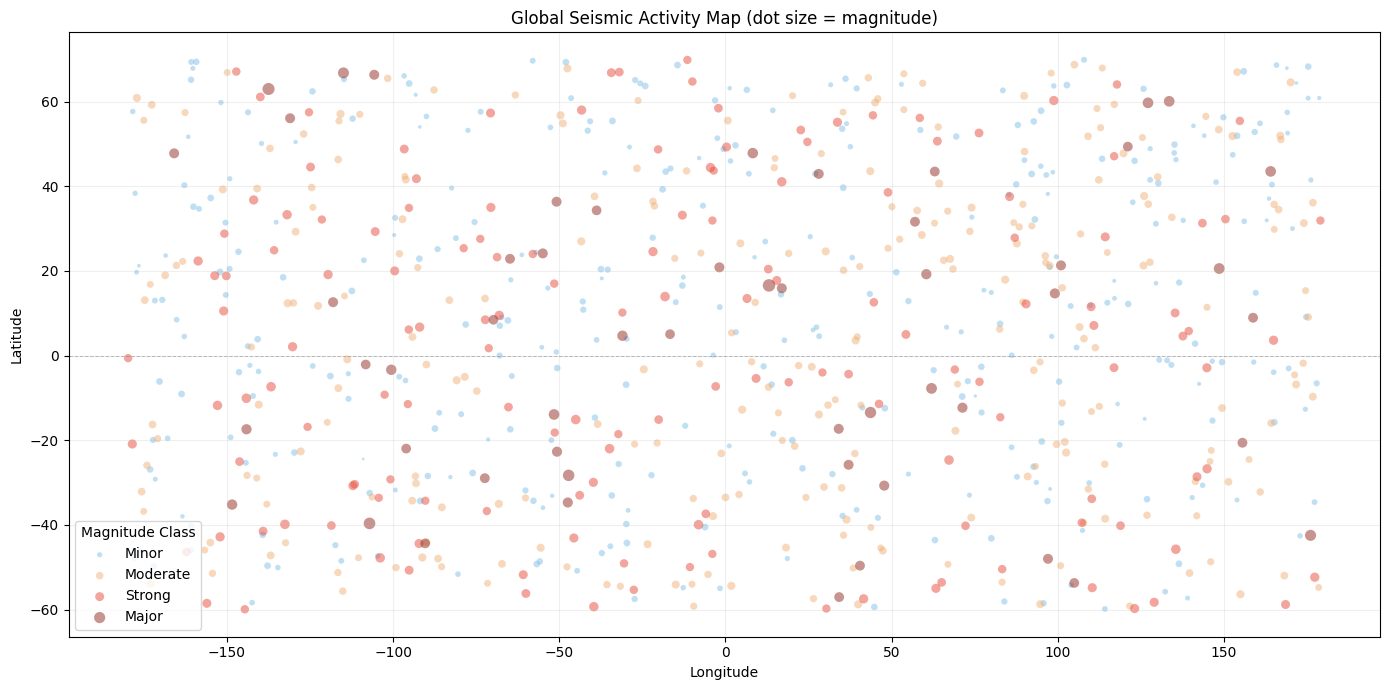

In [15]:
# ── 5.2 Geographic scatter map (latitude vs longitude) ────────────────────
plt.figure(figsize=(14, 7))
cmap_classes = {'Minor':'#85C1E9', 'Moderate':'#F0B27A', 'Strong':'#E74C3C', 'Major':'#922B21'}
for cls, grp in df.groupby('magnitude_class'):
    plt.scatter(grp['longitude'], grp['latitude'], alpha=0.5,
                s=grp['magnitude']**2, label=str(cls),
                color=cmap_classes.get(str(cls), 'grey'), edgecolors='none')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Global Seismic Activity Map (dot size = magnitude)')
plt.legend(title='Magnitude Class', loc='lower left')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## Section 6: TensorFlow Tensors

This section introduces TensorFlow tensors — the fundamental data structure used in deep learning — and demonstrates how they relate to NumPy arrays.

In [16]:
# ── 6.1 Creating tensors ───────────────────────────────────────────────────
print('=== Tensor Creation ===')

# From Python list
t1 = tf.constant([5.2, 6.1, 4.8, 7.3, 3.9], dtype=tf.float32)
print(f'From list    : {t1}')

# From NumPy array
mag_tensor = tf.constant(df['magnitude'].values[:10], dtype=tf.float32)
print(f'From NumPy   : {mag_tensor}')

# 2D tensor (feature matrix)
feature_cols = ['magnitude', 'depth_km', 'felt_radius_km', 'duration_sec']
feature_np   = df[feature_cols].values[:5].astype(np.float32)
feature_tensor = tf.constant(feature_np)
print(f'\n2D Feature Tensor:\n{feature_tensor}')
print(f'Shape  : {feature_tensor.shape}')
print(f'Dtype  : {feature_tensor.dtype}')
print(f'Rank   : {tf.rank(feature_tensor).numpy()}')

=== Tensor Creation ===
From list    : [5.2 6.1 4.8 7.3 3.9]
From NumPy   : [4.4 5.8 4.9 5.3 4.3 4.9 6.5 5.8 5.4 5.2]

2D Feature Tensor:
[[   4.4    5.4  453.4   42.5]
 [   5.8  162.4 1500.    44. ]
 [   4.9  233.4  757.8   45.5]
 [   5.3   24.2 1494.4   45.4]
 [   4.3   39.9  377.7   39.7]]
Shape  : (5, 4)
Dtype  : <dtype: 'float32'>
Rank   : 2


In [17]:
# ── 6.2 Tensor operations ──────────────────────────────────────────────────
print('=== Tensor Operations ===')
t_a = tf.constant([5.2, 6.1, 4.8], dtype=tf.float32)
t_b = tf.constant([4.5, 5.8, 7.1], dtype=tf.float32)

print(f'a          : {t_a.numpy()}')
print(f'b          : {t_b.numpy()}')
print(f'a + b      : {tf.add(t_a, t_b).numpy()}')
print(f'a * b      : {tf.multiply(t_a, t_b).numpy()}')
print(f'mean(a)    : {tf.reduce_mean(t_a).numpy():.4f}')
print(f'max(b)     : {tf.reduce_max(t_b).numpy():.4f}')
print(f'sum(a)     : {tf.reduce_sum(t_a).numpy():.4f}')

# Matrix multiplication
m1 = tf.constant([[1.0, 2.0],[3.0, 4.0]])
m2 = tf.constant([[5.0, 6.0],[7.0, 8.0]])
print(f'\nMatMul result:\n{tf.matmul(m1, m2).numpy()}')

=== Tensor Operations ===
a          : [5.2 6.1 4.8]
b          : [4.5 5.8 7.1]
a + b      : [ 9.7 11.9 11.9]
a * b      : [23.4  35.38 34.08]
mean(a)    : 5.3667
max(b)     : 7.1000
sum(a)     : 16.1000

MatMul result:
[[19. 22.]
 [43. 50.]]


In [18]:
# ── 6.3 Tensor vs NumPy interoperability ──────────────────────────────────
print('=== Tensor <-> NumPy Interoperability ===')

# NumPy array -> Tensor
np_array   = df['magnitude'].values[:5]
tensor_from_np = tf.convert_to_tensor(np_array, dtype=tf.float32)
print(f'NumPy -> Tensor : {tensor_from_np}')

# Tensor -> NumPy
back_to_np = tensor_from_np.numpy()
print(f'Tensor -> NumPy : {back_to_np}')
print(f'Type            : {type(back_to_np)}')

# Variables (mutable tensors)
print('\n=== tf.Variable (Mutable Tensor) ===')
weight = tf.Variable(0.5, dtype=tf.float32)
print(f'Initial weight : {weight.numpy()}')
weight.assign(0.8)
print(f'After assign   : {weight.numpy()}')
weight.assign_add(0.1)
print(f'After add      : {weight.numpy()}')

=== Tensor <-> NumPy Interoperability ===
NumPy -> Tensor : [4.4 5.8 4.9 5.3 4.3]
Tensor -> NumPy : [4.4 5.8 4.9 5.3 4.3]
Type            : <class 'numpy.ndarray'>

=== tf.Variable (Mutable Tensor) ===
Initial weight : 0.5
After assign   : 0.800000011920929
After add      : 0.9000000357627869


In [19]:
# ── 6.4 Tensor shapes, reshaping, and slicing ──────────────────────────────
print('=== Tensor Shape Operations ===')

seismic_tensor = tf.constant(df[feature_cols].values[:20], dtype=tf.float32)
print(f'Original shape : {seismic_tensor.shape}')

# Reshape
reshaped = tf.reshape(seismic_tensor, [4, 5, 4])
print(f'Reshaped (4,5,4): {reshaped.shape}')

# Slicing
first_col = seismic_tensor[:, 0]   # first feature (magnitude) for all rows
print(f'\nSlice [:, 0] (magnitude col): {first_col.numpy()}')

# Normalisation as a tensor operation
mean = tf.reduce_mean(seismic_tensor, axis=0)
std  = tf.math.reduce_std(seismic_tensor, axis=0)
normalised_tensor = (seismic_tensor - mean) / std
print(f'\nNormalised tensor (first row): {normalised_tensor[0].numpy().round(4)}')
print(f'\nAll tensor operations complete. Environment tour finished.')

=== Tensor Shape Operations ===
Original shape : (20, 4)
Reshaped (4,5,4): (4, 5, 4)

Slice [:, 0] (magnitude col): [4.4 5.8 4.9 5.3 4.3 4.9 6.5 5.8 5.4 5.2 6.  5.9 4.7 6.5 6.1 6.9 4.4 5.7
 4.1 7.3]

Normalised tensor (first row): [-1.2548 -1.072  -1.4784 -0.3165]

All tensor operations complete. Environment tour finished.


---
## Summary

This lab covered the complete Python data science environment using a Global Seismic Activity dataset:

| Library | Key Operations Demonstrated |
|---|---|
| **NumPy** | Array creation, statistics, broadcasting, Boolean masking, np.where, np.corrcoef |
| **Pandas** | DataFrame exploration, missing value handling, feature engineering, groupby, pd.cut |
| **Scikit-Learn** | LabelEncoder, StandardScaler, MinMaxScaler, Pipeline, LogisticRegression |
| **Matplotlib/Seaborn** | Histogram, scatter, bar, boxplot, pie, line chart, heatmap, geo-scatter |
| **TensorFlow Tensors** | Tensor creation, arithmetic ops, matmul, reshape, slice, Variable, NumPy conversion |

The seismic analysis confirmed that earthquake magnitude is the strongest predictor of both felt radius and aftershock count. Shallow earthquakes (depth < 70 km) account for the overwhelming majority of tsunami warnings. The Logistic Regression pipeline achieved strong accuracy in predicting tsunami warnings using magnitude and depth as the most influential features.